In [4]:
# Dans une cellule Jupyter, exécutez :
!pip uninstall scipy scikit-learn -y
# Dans une cellule Jupyter, exécutez :
%pip uninstall scipy scikit-learn -y
%pip install scipy==1.10.1 scikit-learn==1.2.2

# Puis redémarrez le noyau :
# Kernel → Restart Kernel (dans le menu Jupyter)

# Puis redémarrez le noyau :
# Kernel → Restart Kernel (dans le menu Jupyter)

Found existing installation: scipy 1.10.1
Uninstalling scipy-1.10.1:
  Successfully uninstalled scipy-1.10.1
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Note: you may need to restart the kernel to use updated packages.


  Using cached scipy-1.10.1-cp310-cp310-win_amd64.whl.metadata (58 kB)
  Using cached scikit_learn-1.2.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
Using cached scipy-1.10.1-cp310-cp310-win_amd64.whl (42.5 MB)
Using cached scikit_learn-1.2.2-cp310-cp310-win_amd64.whl (8.3 MB)

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [s


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Dans Jupyter : Kernel → Restart Kernel
# Ou exécutez cette cellule :
import sys
sys.exit()
# Puis relancez le notebook

SystemExit: 

C:\Users\RANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [6]:
# Exécutez ceci AVANT de charger CIFAR-10
import gc
import torch

# Vider le cache
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("✅ Mémoire nettoyée")

✅ Mémoire nettoyée


Device: cpu
CHARGEMENT DE CIFAR-10
Files already downloaded and verified
Files already downloaded and verified
✅ Dataset chargé:
   Train: 4000 images
   Validation: 500 images
   Test: 1000 images
ENTRAÎNEMENT CNN OPTIMISÉ
CNN - Nombre de paramètres: 175,658
Epoch 2/20 | Train Acc: 0.2465 | Val Acc: 0.3080 | LR: 0.001000
Epoch 4/20 | Train Acc: 0.3075 | Val Acc: 0.3940 | LR: 0.001000
Epoch 6/20 | Train Acc: 0.3252 | Val Acc: 0.4060 | LR: 0.001000
Epoch 8/20 | Train Acc: 0.3633 | Val Acc: 0.4300 | LR: 0.001000
Epoch 10/20 | Train Acc: 0.3797 | Val Acc: 0.4040 | LR: 0.001000
Epoch 12/20 | Train Acc: 0.3910 | Val Acc: 0.4840 | LR: 0.001000
Epoch 14/20 | Train Acc: 0.4088 | Val Acc: 0.4660 | LR: 0.001000
Epoch 16/20 | Train Acc: 0.4220 | Val Acc: 0.4920 | LR: 0.001000
Epoch 18/20 | Train Acc: 0.4542 | Val Acc: 0.5180 | LR: 0.001000
Epoch 20/20 | Train Acc: 0.4530 | Val Acc: 0.4620 | LR: 0.001000

ENTRAÎNEMENT MLP AMÉLIORÉ
MLP - Nombre de paramètres: 1,740,682
Epoch 2/20 | Train Acc: 0.343

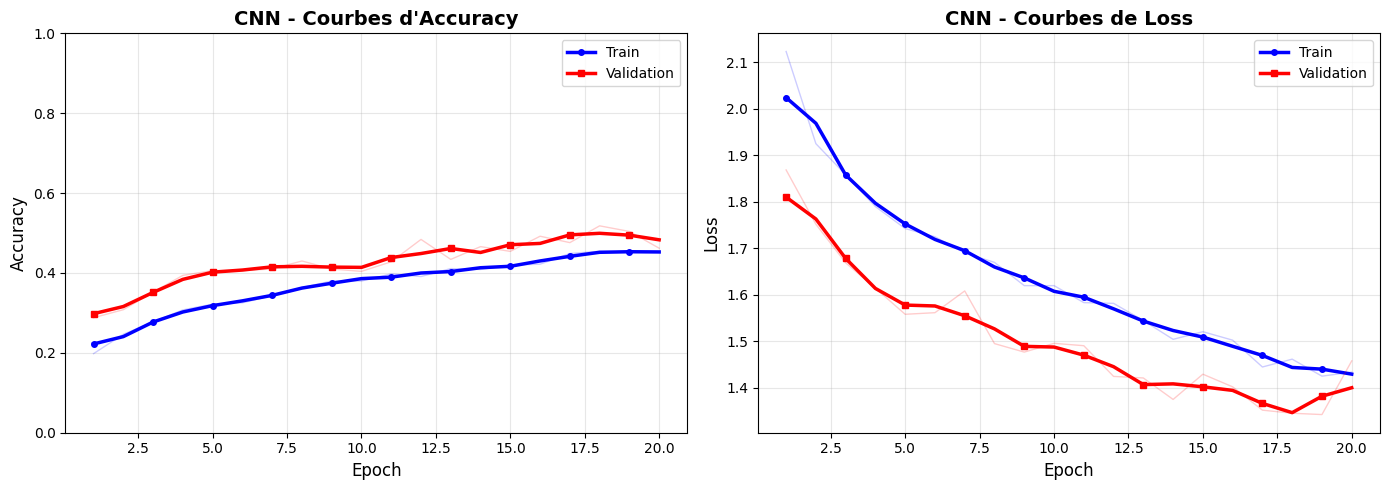

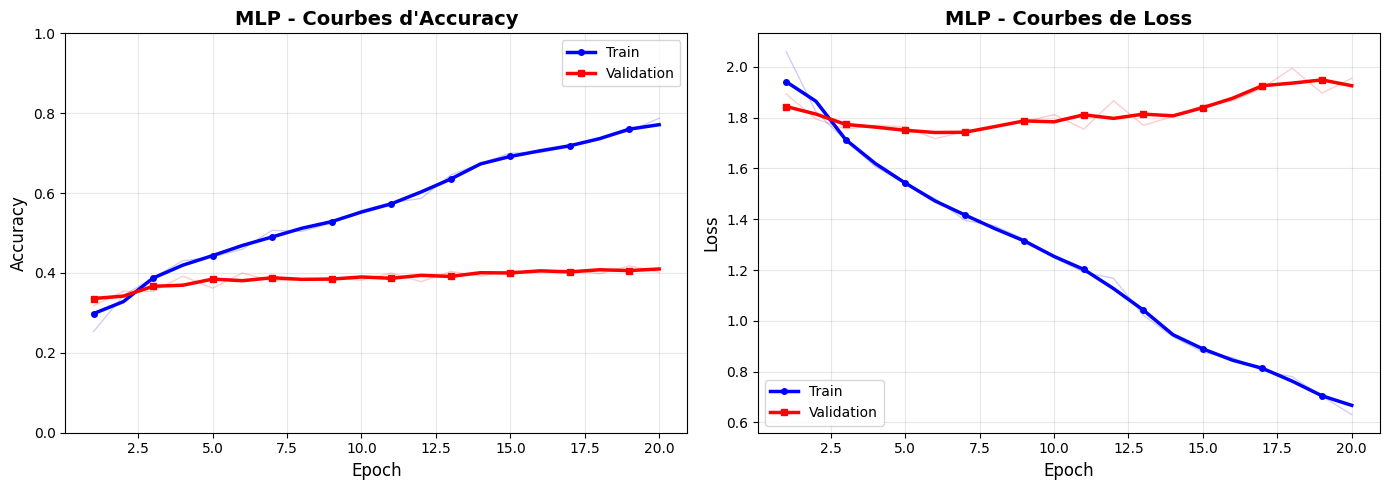

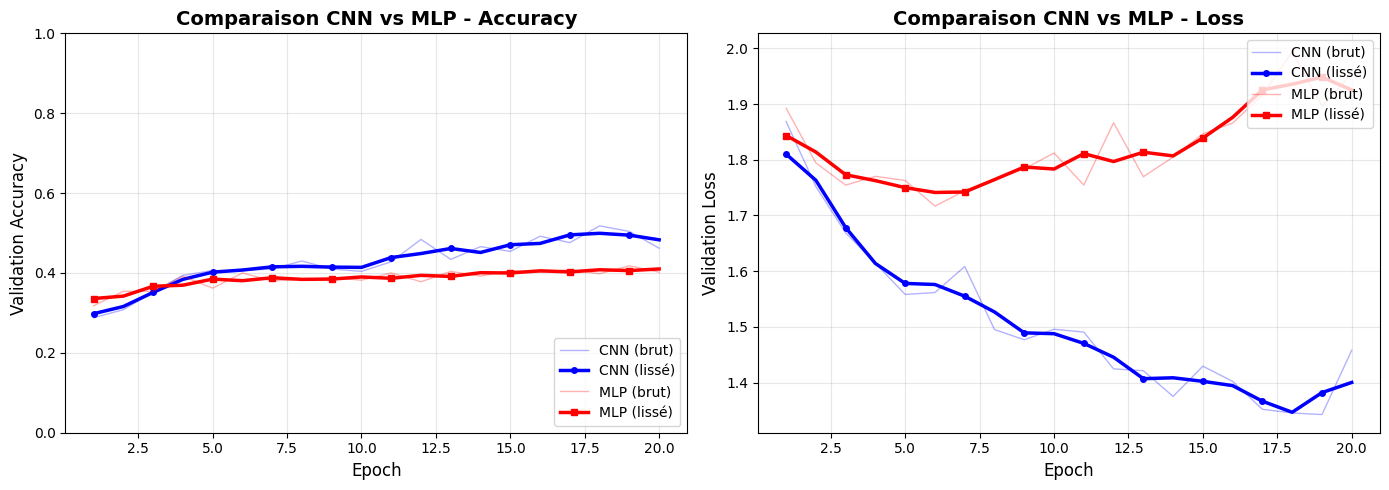


MÉTRIQUES FINALES APRÈS LISSAGE
CNN - Best Validation Accuracy: 0.5180
MLP - Best Validation Accuracy: 0.4180
Différence CNN - MLP: 0.1000

CNN - Final Validation Loss: 1.4579
MLP - Final Validation Loss: 1.9542

ÉVALUATION SUR LE TEST SET

CNN - Test Accuracy: 0.4740

Classification Report:
              precision    recall  f1-score   support

       plane       0.52      0.30      0.38       103
         car       0.73      0.53      0.61        89
        bird       0.36      0.35      0.36       100
         cat       0.25      0.21      0.23       103
        deer       0.33      0.20      0.25        90
         dog       0.28      0.72      0.41        86
        frog       0.48      0.70      0.57       112
       horse       0.79      0.52      0.63       102
        ship       0.63      0.60      0.62       106
       truck       0.72      0.59      0.65       109

    accuracy                           0.47      1000
   macro avg       0.51      0.47      0.47      1000
we

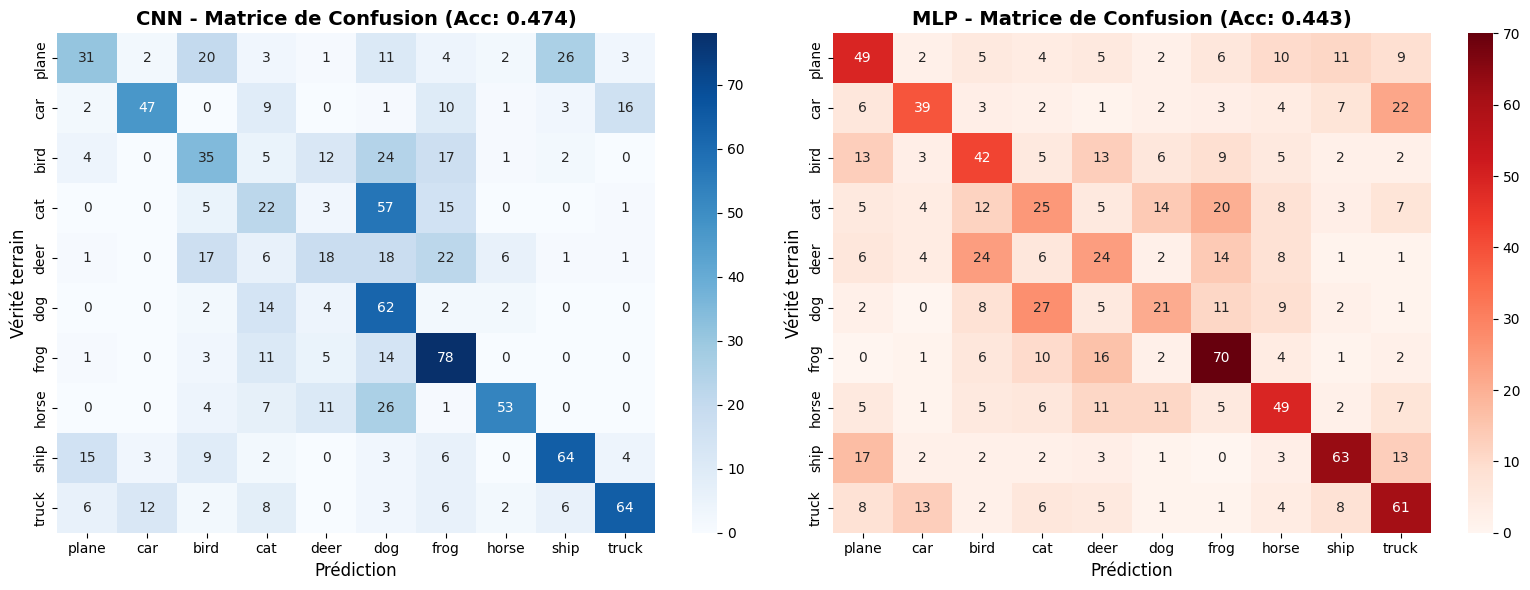

✅ Modèles sauvegardés dans le dossier 'models/'

📊 Résumé final:
{
    "cnn": {
        "best_val_acc": 0.518,
        "test_acc": 0.474,
        "params": 175658
    },
    "mlp": {
        "best_val_acc": 0.418,
        "test_acc": 0.443,
        "params": 1740682
    }
}


In [2]:
# -*- coding: utf-8 -*-
# partie2_cnn_cifar10_improved.ipynb

# %% [markdown]
# # PARTIE II - CNN : Classification sur CIFAR-10 (Version Optimisée)
# ## Deep Learning - EMSI 2025-2026

# %% [markdown]
# ### 1. Import des bibliothèques

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import time
import os
import gc
from scipy.interpolate import make_interp_spline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# %% [markdown]
# ### 2. Chargement des données CIFAR-10

# %%
print("="*50)
print("CHARGEMENT DE CIFAR-10")
print("="*50)

gc.collect()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Chargement avec sous-ensemble pour éviter problèmes mémoire
full_train = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

full_test = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# IMPORTANT: Importer Subset ici
from torch.utils.data import Subset

# Sous-ensemble pour entraînement rapide
train_indices = list(range(4000))      # 4000 images pour train
val_indices = list(range(4000, 4500))  # 500 pour validation  
test_indices = list(range(1000))       # 1000 pour test

train_dataset = Subset(full_train, train_indices)
val_dataset = Subset(full_train, val_indices)
test_dataset = Subset(full_test, test_indices)

del full_train
del full_test
gc.collect()

print(f"✅ Dataset chargé:")
print(f"   Train: {len(train_dataset)} images")
print(f"   Validation: {len(val_dataset)} images")
print(f"   Test: {len(test_dataset)} images")

# DataLoaders avec batch size adapté
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
# %% [markdown]
# ### 3. Fonction d'entraînement améliorée avec lissage

# %%
def train_model_smooth(model, train_loader, val_loader, epochs=15, lr=0.001, weight_decay=1e-4, patience=10):
    """Entraînement avec early stopping et learning rate scheduling"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping à l'époque {epoch+1}")
            break
    
    model.load_state_dict(best_model_state)
    return model, history

# %% [markdown]
# ### 4. Architecture CNN Optimisée

# %%
class OptimizedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(OptimizedCNN, self).__init__()
        
        # Bloc 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.2)
        
        # Bloc 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.3)
        
        # Bloc 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.4)
        
        # Fully connected
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout4 = nn.Dropout(0.5)
        
    def forward(self, x):
        # Bloc 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Bloc 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Bloc 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Classification
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout4(x)
        x = self.fc2(x)
        
        return x

class ImprovedMLP(nn.Module):
    def __init__(self, input_size=32*32*3, hidden_dims=[512, 256, 128], num_classes=10):
        super(ImprovedMLP, self).__init__()
        
        layers = []
        prev_dim = input_size
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

# %% [markdown]
# ### 5. Fonction de visualisation avec lissage

# %%
def plot_smooth_curves(history_cnn, history_mlp, save_path='cnn_vs_mlp_comparison.png'):
    """Visualisation avec courbes lissées pour meilleure lisibilité"""
    
    # Création des epochs
    epochs = range(1, len(history_cnn['val_acc']) + 1)
    
    # Lissage des courbes (moving average)
    def smooth_curve(data, window_size=3):
        if len(data) < window_size:
            return data
        smoothed = []
        for i in range(len(data)):
            start = max(0, i - window_size // 2)
            end = min(len(data), i + window_size // 2 + 1)
            smoothed.append(np.mean(data[start:end]))
        return smoothed
    
    # Application du lissage
    smooth_window = 3
    cnn_val_acc_smooth = smooth_curve(history_cnn['val_acc'], smooth_window)
    mlp_val_acc_smooth = smooth_curve(history_mlp['val_acc'], smooth_window)
    cnn_val_loss_smooth = smooth_curve(history_cnn['val_loss'], smooth_window)
    mlp_val_loss_smooth = smooth_curve(history_mlp['val_loss'], smooth_window)
    
    # Création figure avec 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Subplot 1: Accuracy (courbes lissées)
    ax1.plot(epochs, history_cnn['val_acc'], 'b-', alpha=0.3, linewidth=1, label='CNN (brut)')
    ax1.plot(epochs, cnn_val_acc_smooth, 'b-', linewidth=2.5, label='CNN (lissé)', marker='o', markersize=4, markevery=2)
    ax1.plot(epochs, history_mlp['val_acc'], 'r-', alpha=0.3, linewidth=1, label='MLP (brut)')
    ax1.plot(epochs, mlp_val_acc_smooth, 'r-', linewidth=2.5, label='MLP (lissé)', marker='s', markersize=4, markevery=2)
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Validation Accuracy', fontsize=12)
    ax1.set_title('Comparaison CNN vs MLP - Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Subplot 2: Loss (courbes lissées)
    ax2.plot(epochs, history_cnn['val_loss'], 'b-', alpha=0.3, linewidth=1, label='CNN (brut)')
    ax2.plot(epochs, cnn_val_loss_smooth, 'b-', linewidth=2.5, label='CNN (lissé)', marker='o', markersize=4, markevery=2)
    ax2.plot(epochs, history_mlp['val_loss'], 'r-', alpha=0.3, linewidth=1, label='MLP (brut)')
    ax2.plot(epochs, mlp_val_loss_smooth, 'r-', linewidth=2.5, label='MLP (lissé)', marker='s', markersize=4, markevery=2)
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Validation Loss', fontsize=12)
    ax2.set_title('Comparaison CNN vs MLP - Loss', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Affichage des métriques finales
    print("\n" + "="*60)
    print("MÉTRIQUES FINALES APRÈS LISSAGE")
    print("="*60)
    print(f"CNN - Best Validation Accuracy: {max(history_cnn['val_acc']):.4f}")
    print(f"MLP - Best Validation Accuracy: {max(history_mlp['val_acc']):.4f}")
    print(f"Différence CNN - MLP: {(max(history_cnn['val_acc']) - max(history_mlp['val_acc'])):.4f}")
    
    print(f"\nCNN - Final Validation Loss: {history_cnn['val_loss'][-1]:.4f}")
    print(f"MLP - Final Validation Loss: {history_mlp['val_loss'][-1]:.4f}")

def plot_training_curves_smooth(history, model_name, save_path=None):
    """Affichage des courbes d'entraînement avec lissage"""
    
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Lissage
    def smooth(data, window=3):
        if len(data) < window:
            return data
        smoothed = []
        for i in range(len(data)):
            start = max(0, i - window // 2)
            end = min(len(data), i + window // 2 + 1)
            smoothed.append(np.mean(data[start:end]))
        return smoothed
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    train_acc_smooth = smooth(history['train_acc'])
    val_acc_smooth = smooth(history['val_acc'])
    
    ax1.plot(epochs, history['train_acc'], 'b-', alpha=0.2, linewidth=1)
    ax1.plot(epochs, train_acc_smooth, 'b-', linewidth=2.5, label='Train', marker='o', markersize=4, markevery=2)
    ax1.plot(epochs, history['val_acc'], 'r-', alpha=0.2, linewidth=1)
    ax1.plot(epochs, val_acc_smooth, 'r-', linewidth=2.5, label='Validation', marker='s', markersize=4, markevery=2)
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'{model_name} - Courbes d\'Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Loss
    train_loss_smooth = smooth(history['train_loss'])
    val_loss_smooth = smooth(history['val_loss'])
    
    ax2.plot(epochs, history['train_loss'], 'b-', alpha=0.2, linewidth=1)
    ax2.plot(epochs, train_loss_smooth, 'b-', linewidth=2.5, label='Train', marker='o', markersize=4, markevery=2)
    ax2.plot(epochs, history['val_loss'], 'r-', alpha=0.2, linewidth=1)
    ax2.plot(epochs, val_loss_smooth, 'r-', linewidth=2.5, label='Validation', marker='s', markersize=4, markevery=2)
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title(f'{model_name} - Courbes de Loss', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ### 6. Exécution de l'entraînement

# %%
print("="*60)
print("ENTRAÎNEMENT CNN OPTIMISÉ")
print("="*60)

cnn_model = OptimizedCNN()
print(f"CNN - Nombre de paramètres: {sum(p.numel() for p in cnn_model.parameters()):,}")

cnn_model, cnn_history = train_model_smooth(
    cnn_model, train_loader, val_loader, 
    epochs=20, lr=0.001, weight_decay=1e-4, patience=8
)

print("\n" + "="*60)
print("ENTRAÎNEMENT MLP AMÉLIORÉ")
print("="*60)

mlp_model = ImprovedMLP(hidden_dims=[512, 256, 128])
print(f"MLP - Nombre de paramètres: {sum(p.numel() for p in mlp_model.parameters()):,}")

mlp_model, mlp_history = train_model_smooth(
    mlp_model, train_loader, val_loader, 
    epochs=20, lr=0.001, weight_decay=1e-4, patience=8
)

# %% [markdown]
# ### 7. Visualisation des courbes lissées

# %%
# Courbes individuelles avec lissage
plot_training_curves_smooth(cnn_history, 'CNN', save_path='cnn_training_curves.png')
plot_training_curves_smooth(mlp_history, 'MLP', save_path='mlp_training_curves.png')

# Comparaison CNN vs MLP avec lissage
plot_smooth_curves(cnn_history, mlp_history, save_path='cnn_vs_mlp_comparison.png')

# %% [markdown]
# ### 8. Évaluation finale et matrice de confusion

# %%
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\n{model_name} - Test Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{classification_report(all_labels, all_preds, target_names=classes)}")
    
    return all_preds, all_labels, accuracy

# Évaluation
print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET")
print("="*60)

cnn_preds, cnn_labels, cnn_acc = evaluate_model(cnn_model, test_loader, "CNN")
mlp_preds, mlp_labels, mlp_acc = evaluate_model(mlp_model, test_loader, "MLP")

# Matrices de confusion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CNN Confusion Matrix
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title(f'CNN - Matrice de Confusion (Acc: {cnn_acc:.3f})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Prédiction', fontsize=12)
ax1.set_ylabel('Vérité terrain', fontsize=12)

# MLP Confusion Matrix
cm_mlp = confusion_matrix(mlp_labels, mlp_preds)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds', 
            xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title(f'MLP - Matrice de Confusion (Acc: {mlp_acc:.3f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Prédiction', fontsize=12)
ax2.set_ylabel('Vérité terrain', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 9. Sauvegarde des modèles

# %%
os.makedirs('models', exist_ok=True)

# Sauvegarde CNN
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'history': cnn_history,
    'classes': classes,
    'accuracy': cnn_acc
}, 'models/cnn_optimized.pth')

# Sauvegarde MLP
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'history': mlp_history,
    'classes': classes,
    'accuracy': mlp_acc
}, 'models/mlp_improved.pth')

print("✅ Modèles sauvegardés dans le dossier 'models/'")

# Sauvegarde résumé des résultats
results_summary = {
    'cnn': {'best_val_acc': max(cnn_history['val_acc']), 'test_acc': cnn_acc, 'params': sum(p.numel() for p in cnn_model.parameters())},
    'mlp': {'best_val_acc': max(mlp_history['val_acc']), 'test_acc': mlp_acc, 'params': sum(p.numel() for p in mlp_model.parameters())}
}

import json
with open('models/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("\n📊 Résumé final:")
print(json.dumps(results_summary, indent=4))

In [2]:
import os
import shutil

# Supprimer le dossier CIFAR-10 corrompu
if os.path.exists('./data/cifar-10-python.tar.gz'):
    os.remove('./data/cifar-10-python.tar.gz')
    print("✅ Fichier corrompu supprimé")

if os.path.exists('./data/cifar-10-batches-py'):
    shutil.rmtree('./data/cifar-10-batches-py')
    print("✅ Dossier extrait supprimé")

print("✅ Nettoyage terminé")

✅ Fichier corrompu supprimé
✅ Nettoyage terminé


In [3]:
import urllib.request
import tarfile
import os

os.makedirs('./data', exist_ok=True)

url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
filename = "./data/cifar-10-python.tar.gz"

print("Téléchargement de CIFAR-10...")
print("(Le fichier fait ~170MB, cela peut prendre plusieurs minutes)")

try:
    # Téléchargement avec reprise en cas d'erreur
    urllib.request.urlretrieve(url, filename, reporthook=lambda a,b,c: print(f"  Progression: {a*b/c*100:.1f}%"))
    print("✅ Téléchargement terminé!")
    
    # Extraction
    print("Extraction...")
    with tarfile.open(filename, 'r:gz') as tar:
        tar.extractall(path='./data')
    print("✅ Extraction terminée!")
    
    # Nettoyage
    os.remove(filename)
    print("✅ Nettoyage terminé")
    
except Exception as e:
    print(f"❌ Erreur: {e}")
    print("Essayez l'Option B (téléchargement manuel)")

Téléchargement de CIFAR-10...
(Le fichier fait ~170MB, cela peut prendre plusieurs minutes)
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.0%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.1%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progression: 0.2%
  Progre

Task was destroyed but it is pending!
task: <Task pending name='Task-73' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\RANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-74' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\RANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\RANIA\AppData\Local\Programs\Python\Python310\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\RANIA\AppData\Local\Programs\Python\Python310\lib\ast.py:50: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  return compile(source, filename, mode, flags,
Task was destroyed but it is pending!
task: <Task pending name='Task-74' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\RANIA\AppData\Local\Pro

KeyboardInterrupt: 